In [105]:
import simpeg.electromagnetics.time_domain as tdem
from simpeg.utils import plot_1d_layer_model, download, mkvc
from simpeg import (
    maps,
    data,
    data_misfit,
    regularization,
    optimization,
    inverse_problem,
    inversion,
    directives,
)
from discretize import TensorMesh
import empymod as empy

In [106]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import pandas as pd

In [107]:
mpl.rcParams.update({"font.size":14, "font.family":"Times New Roman"})

In [108]:
istart = 1
times = (np.array([
    104.9, 132.7, 160.5, 188.3, 229.9,
    285.5, 341, 396.6, 452.2, 507.7,
    563.3, 618.8, 688.3, 771.6, 854.9,
    938.3, 1021.6, 1118.8, 1229.9, 1341.0,
    1466.0, 1604.9, 1743.8, 1896.6, 2063.3,
    2229.9, 2410.5, 2604.9, 2813.3, 3035.5
    ]) * 1e-6)[istart:]

In [109]:
area:str = "NE"
path:str = f"../data/11-024_Alberta_{area}.csv"
picker:list = ["Line", "bheight", "TranPeak", "x_wgs84", "y_wgs84", "flight"]\
    + [f"zoff30[{i}]" for i in range(30)]

In [110]:
# Load data
dobs_total = pd.read_csv(path)[picker]

In [111]:
dobs_total.head()

,Line,bheight,TranPeak,x_wgs84,y_wgs84,flight,zoff30[0],zoff30[1],zoff30[2],zoff30[3],...,zoff30[20],zoff30[21],zoff30[22],zoff30[23],zoff30[24],zoff30[25],zoff30[26],zoff30[27],zoff30[28],zoff30[29]
0,L10040,51.911278,458.3756,402493.257158,5.641032e+06,503,4554.725041,3266.915041,2627.075041,2210.225041,...,101.325041,81.035041,64.625041,50.545041,40.495041,28.595041,20.135041,17.725041,11.095041,4.355041
1,L10040,51.951504,458.3796,402494.415637,5.641030e+06,503,4545.241420,3259.371420,2621.841420,2206.031420,...,101.021420,80.681420,64.331420,50.241420,40.191420,28.141420,19.751420,17.621420,10.931420,4.231420
2,L10040,51.990196,458.3752,402495.574117,5.641028e+06,503,4536.177913,3251.867913,2616.617913,2201.817913,...,100.717913,80.387913,64.067913,49.897913,39.827913,27.707913,19.367913,17.547913,10.687913,4.137913
3,L10040,52.028530,458.3842,402496.732597,5.641026e+06,503,4528.109667,3244.549667,2611.509667,2197.669667,...,100.479667,80.169667,63.829667,49.569667,39.469667,27.359667,19.069667,17.509667,10.379667,4.069667
4,L10040,52.065350,458.3826,402497.891079,5.641024e+06,503,4521.036778,3237.416778,2606.496778,2193.566778,...,100.266778,80.016778,63.626778,49.266778,39.096778,27.046778,18.826778,17.456778,10.066778,4.016778


In [112]:
index = 1000
altitude = dobs_total.iloc[index,1]
currents = dobs_total.iloc[index,2]

In [113]:
n_turns:int = 5 # Number of turns in the transmitter loop
normalizer = 1e-9/currents/n_turns
# Noarmalize data by the current and number of turns, and convert to seconds. (sign is flipped to match simpeg forward modeling)
dobs = (-1)*dobs_total.iloc[index,6:][istart:]*normalizer

In [114]:
print(dobs_total["x_wgs84"][index], dobs_total["y_wgs84"][index])
del dobs_total

403225.666469939 5638611.07159811


## Defining the Survey

In [115]:
# Source loop geometry
source_location = np.array([0.0, 0.0, altitude])  # (3, ) numpy.array_like
source_orientation = "z"  # "x", "y" or "z"
source_current = 1 # maximum on-time current (A)
source_radius = 5  # source loop radius (m)

# Receiver geometry
receiver_location = np.array([0.0, 0.0, altitude])  # or (N, 3) numpy.ndarray
receiver_orientation = "z"  # "x", "y" or "z"

# Receiver list
receiver_list = []
receiver_list.append(
    tdem.receivers.PointMagneticFluxTimeDerivative(
        receiver_location, times, orientation=receiver_orientation
    )
)

In [116]:
# Define the source waveform. (unit step-off, rectangular, triangular, quarter-sine, custom)
# Triangular waveform. 
start_time = -1.74e-3
peak_time = -0.84e-3
off_time = 0.0
waveform = tdem.sources.TriangularWaveform(
    start_time,
    off_time,
    peak_time
)

In [117]:
# Sources
source_list = [
    tdem.sources.CircularLoop(
        receiver_list=receiver_list,
        location=source_location,
        orientation=source_orientation,
        waveform=waveform,
        current=source_current,
        radius=source_radius,
    )
]

# Survey
survey = tdem.Survey(source_list)

In [118]:
# field normalization with 0.05 % of each data point and add 5nT noise floor
uncertainties = 0.05 * np.abs(dobs) * np.ones(np.shape(dobs)) + 5 * normalizer # 5nT noise floor

In [119]:
data_object = data.Data(survey, dobs=dobs, standard_deviation=uncertainties)

In [120]:
# estimated host conductivity (S/m)
estimated_conductivity = 1e-2
# minimum diffusion distance
d_min = 1250 * np.sqrt(times.min() / estimated_conductivity)
print("MINIMUM DIFFUSION DISTANCE: {} m".format(d_min))
# maximum diffusion distance
d_max = 1250 * np.sqrt(times.max() / estimated_conductivity)
print("MAXIMUM DIFFUSION DISTANCE: {} m".format(d_max))

MINIMUM DIFFUSION DISTANCE: 143.99435752834205 m
MAXIMUM DIFFUSION DISTANCE: 688.6921482055681 m


In [121]:
depth_min = 5  # top layer thickness
depth_max = 250.0  # depth to lowest layer
geometric_factor = 1.15  # rate of thickness increase

In [122]:
# Increase subsequent layer thicknesses by the geometric factors until
# it reaches the maximum layer depth.
layer_thicknesses = [depth_min]
while np.sum(layer_thicknesses) < depth_max:
    layer_thicknesses.append(geometric_factor * layer_thicknesses[-1])

n_layers = len(layer_thicknesses) + 1  # Number of layers

In [123]:
l_bound = 1e-4
u_bound = 10
log_conductivity_map = maps.LogisticSigmoidMap(nP=n_layers, lower_bound=l_bound, upper_bound=u_bound) # nP is the number of layers

In [124]:
# Starting model is log-conductivity values (S/m)
starting_cond = 7e-2
# starting_conductivity_model = np.log(7e-2 * np.ones(n_layers))
starting_conductivity_model = np.log((starting_cond -l_bound)/(u_bound - starting_cond) * np.ones(n_layers))
# Reference model is also log-resistivity values (S/m)
reference_conductivity_model = starting_conductivity_model.copy()
# reference_conductivity_model = np.log(1e-2 * np.ones(n_layers))

In [125]:
simulation_L2 = tdem.Simulation1DLayered(
    survey=survey, thicknesses=layer_thicknesses, sigmaMap=log_conductivity_map
)

In [126]:
dpred_data = simulation_L2.dpred(starting_conductivity_model)

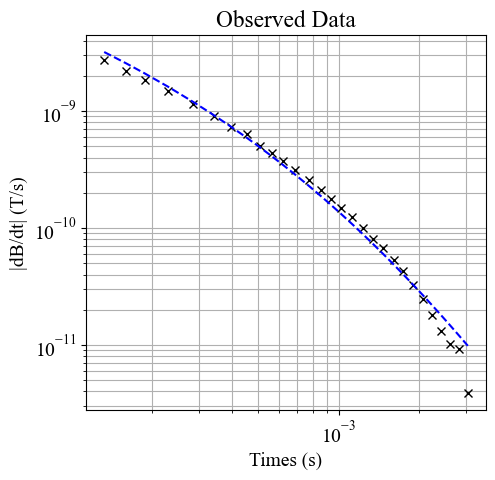

In [127]:
fig = plt.figure(figsize=(5, 5))
ax = fig.add_axes([0.15, 0.15, 0.8, 0.75])
ax.loglog(times, np.abs(dobs), "kx")
ax.loglog(times, np.abs(dpred_data), "b--")
ax.grid(which="both")
ax.set_xlabel("Times (s)")
ax.set_ylabel("|dB/dt| (T/s)")
ax.set_title("Observed Data")
plt.show()

In [128]:
dmis_L2 = data_misfit.L2DataMisfit(simulation=simulation_L2, data=data_object)

In [129]:
# Define 1D cell widths
h = np.r_[layer_thicknesses, layer_thicknesses[-1]]
h = np.flipud(h)

# Create regularization mesh
regularization_mesh = TensorMesh([h], "N")
print(regularization_mesh)


  TensorMesh: 17 cells

                      MESH EXTENT             CELL WIDTH      FACTOR
  dir    nC        min           max         min       max      max
  ---   ---  ---------------------------  ------------------  ------
   x     17       -319.27          0.00      5.00     40.69    1.15




In [130]:
reg_L2 = regularization.WeightedLeastSquares(
    regularization_mesh,
    alpha_s=1e-10,
    # alpha_x=0.0, # weighting for the first derivative term
    length_scale_x=10.0,
    reference_model=reference_conductivity_model,# Log resistivity
    reference_model_in_smooth=False,
)

In [131]:
opt_L2 = optimization.InexactGaussNewton(
    maxIter=20, maxIterLS=20, cg_maxiter=50, cg_rtol=1e-3
)

$$
\phi(m)=\phi_{d}(m)+\beta\cdot\phi_m(m)
$$

**Trade-off Parameter:** $\beta_0 = \text{beta0\_ratio} \cdot \frac{\lambda_{max}(J^T W_d^T W_d J)}{\lambda_{max}(W_m^T W_m)}$

In [132]:
inv_prob_L2 = inverse_problem.BaseInvProblem(dmis_L2, reg_L2, opt_L2)

In [133]:
# Inversion Directives

update_jacobi = directives.UpdatePreconditioner(update_every_iteration=True)
# Initial beta
starting_beta = directives.BetaEstimate_ByEig(beta0_ratio=5)
# Beta schedule: Decrease beta by a factor of 2 every 3 iterations
beta_schedule = directives.BetaSchedule(coolingFactor=2.0, coolingRate=3)
target_misfit = directives.TargetMisfit(chifact=1.0)

directives_list_L2 = [update_jacobi, starting_beta, beta_schedule, target_misfit]

In [134]:
# Here we combine the inverse problem and the set of directives
inv_L2 = inversion.BaseInversion(inv_prob_L2, directives_list_L2)

# Run the inversion
recovered_model_L2 = inv_L2.run(starting_conductivity_model)

# Output Table Columns:
# #:Iteration number
# beta: Trade-off parameter (weighting of the regularization)
# phi_d: Data misfit
# phi_m: Model misfit
# f: Total objective function value (phi_d + beta * phi_m)
# |proj(x-g)-x|: Gradient projection (convergence indicator)
# LS: Line search iterations 


Running inversion with SimPEG v0.25.2


INFO: Directive TargetMisfit: Target data misfit is 29.0


============================ Inexact Gauss Newton ============================
  #     beta     phi_d     phi_m       f      |proj(x-g)-x|  LS    Comment   
-----------------------------------------------------------------------------
   0  3.39e+00  7.93e+01  2.23e-28  7.93e+01                                 
   1  3.39e+00  4.89e+01  2.36e+00  5.69e+01    1.16e+02      0              
   2  3.39e+00  4.85e+01  2.29e+00  5.63e+01    4.16e+01      0              
   3  3.39e+00  4.86e+01  2.28e+00  5.63e+01    1.09e+00      0              
   4  1.70e+00  4.26e+01  4.88e+00  5.09e+01    2.58e+01      0              
   5  1.70e+00  4.29e+01  4.71e+00  5.09e+01    2.97e+00      0              
   6  1.70e+00  4.28e+01  4.73e+00  5.09e+01    2.40e-01      0              
   7  8.48e-01  3.58e+01  1.10e+01  4.51e+01    2.10e+01      0              
   8  8.48e-01  3.63e+01  1.03e+01  4.50e+01    4.26e+00      0              
   9  8.48e-01  3.62e+01  1.04e+01  4.50e+01    4.70e-01      0

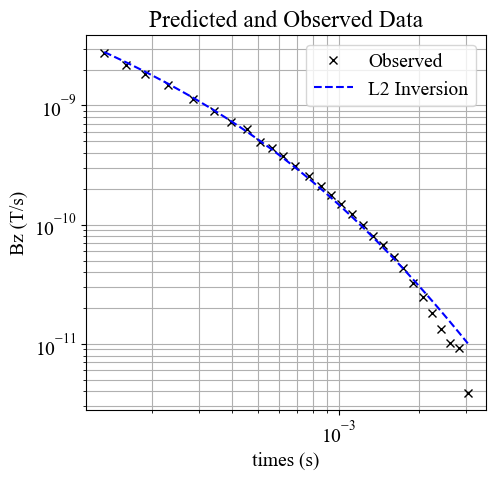

In [135]:
dpred_L2 = simulation_L2.dpred(recovered_model_L2)

fig = plt.figure(figsize=(5, 5))
ax1 = fig.add_axes([0.15, 0.15, 0.8, 0.75])
ax1.loglog(times, np.abs(dobs), "kx")
ax1.loglog(times, np.abs(dpred_L2), "b--")
ax1.grid(which="both")
ax1.set_xlabel("times (s)")
ax1.set_ylabel("Bz (T/s)")
ax1.set_title("Predicted and Observed Data")
ax1.legend(["Observed", "L2 Inversion"], loc="upper right")
plt.show()

In [136]:
recovered_conductivities = log_conductivity_map * recovered_model_L2

In [137]:
final_misfit = dmis_L2(recovered_model_L2)
chi_squared = final_misfit / times.size
print(f"{chi_squared=:.2f}")

chi_squared=0.99


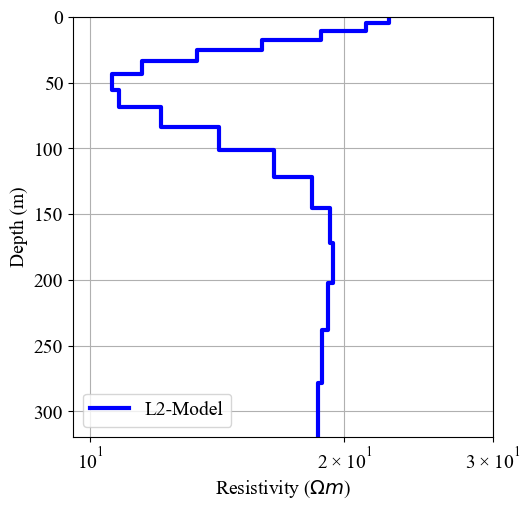

In [142]:
# Plot true model and recovered model
fig = plt.figure(figsize=(6, 6))

ax1 = fig.add_axes([0.2, 0.15, 0.7, 0.7])
plot_1d_layer_model(
    layer_thicknesses, 1/recovered_conductivities, ax=ax1, color="b", lw=3,
)
ax1.grid()
ax1.set_xlabel(r"Resistivity ($\Omega m$)")
ax1.legend(["L2-Model"])
ax1.set_xticks([1e1,2e1,3e1])
plt.show()

In [139]:
1/recovered_conductivities

array([22.59846898, 21.21692682, 18.76322764, 15.96165848, 13.39041141,
       11.50176296, 10.59287024, 10.8101384 , 12.12013288, 14.21459707,
       16.49183039, 18.28349532, 19.21639846, 19.37163181, 19.11403984,
       18.80141688, 18.61329861])